# Parameter sweeps

Train the same model repeatedly while changing one parameter, and measure what it does.

The trap this notebook is built around: **retraining with a different setting always
produces a different number, whether or not the setting mattered.** Two runs that differ
only in random seed also produce different numbers. So before believing any sweep, you
have to know how big the difference is between runs that should be identical — the
*noise floor*. Section 2 measures it, and everything after is read against it.

Each swept model is saved under its own name, so it shows up in the arena and the match
viewer alongside everything else.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from train.sweep import evaluate_model, round_robin, separable, sweep
from vizstyle import (INK_FAINT, INK_SOFT, colour_for, diverging_cmap,
                      finish, new_figure, use_style)

use_style()

# Turn this off for runs you intend to trust. FAST keeps the whole notebook to a
# few minutes, at the cost of wider error bars on every result below.
FAST = True

DQN_EPISODES = 2500 if FAST else 12000
GA_GENERATIONS = 15 if FAST else 40
GA_POPULATION = 30 if FAST else 50
ARENA_GAMES = 300 if FAST else 3000
SEED_REPLICATES = 5

print(f"FAST={FAST}  ·  dqn {DQN_EPISODES} episodes  ·  "
      f"ga {GA_GENERATIONS} gens x {GA_POPULATION}  ·  {ARENA_GAMES} games per measurement")

FAST=True  ·  dqn 2500 episodes  ·  ga 15 gens x 30  ·  300 games per measurement


## 1. DQN hidden layer width

Five network sizes, everything else held constant. Each is trained, then played
against the same `random` opponent on the same seeds.

In [2]:
hidden_rows = sweep(
    "dqn", "snake", "hidden", [16, 32, 64, 128, 256],
    players=2, episodes=DQN_EPISODES, arena_games=ARENA_GAMES,
)
hidden = pd.DataFrame(hidden_rows)
hidden[["hidden", "model", "train_seconds", "mean_score", "stderr", "win_rate"]].round(3)

training dqn-hidden-16 … 

  9.3s train · score     4.16 ± 0.78 · win 86.5%
training dqn-hidden-32 … 

  9.6s train · score     5.54 ± 1.00 · win 89.0%
training dqn-hidden-64 … 

 10.7s train · score    10.11 ± 1.45 · win 93.3%
training dqn-hidden-128 … 

 20.2s train · score    22.05 ± 2.20 · win 98.3%
training dqn-hidden-256 … 

 32.2s train · score    22.52 ± 2.26 · win 99.0%


,hidden,model,train_seconds,mean_score,stderr,win_rate
0,16,dqn-hidden-16,9.3,4.160,0.399,0.865
1,32,dqn-hidden-32,9.6,5.544,0.513,0.890
2,64,dqn-hidden-64,10.7,10.105,0.738,0.933
3,128,dqn-hidden-128,20.2,22.049,1.120,0.983
4,256,dqn-hidden-256,32.2,22.517,1.155,0.990


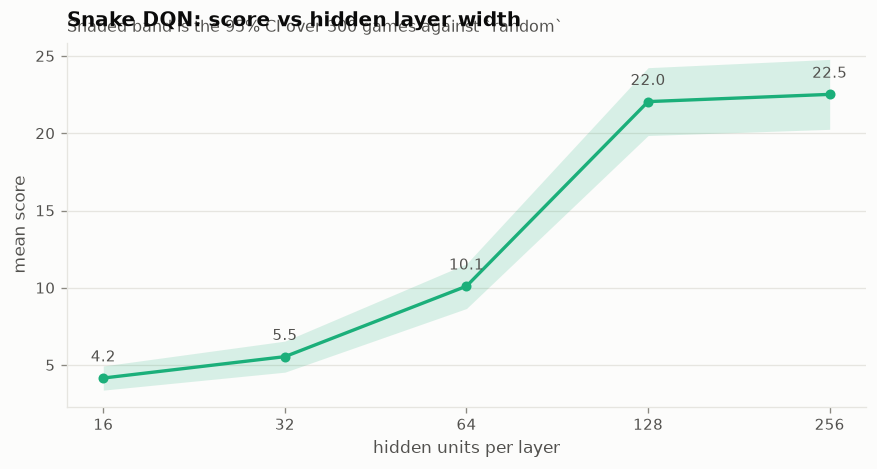

In [3]:
fig, ax = new_figure()
ax.fill_between(hidden["hidden"], hidden["score_low"], hidden["score_high"],
                color=colour_for("dqn"), alpha=0.16, linewidth=0)
ax.plot(hidden["hidden"], hidden["mean_score"], color=colour_for("dqn"), marker="o")
ax.set_xscale("log", base=2)
ax.set_xticks(hidden["hidden"], [str(h) for h in hidden["hidden"]])
for _, row in hidden.iterrows():
    ax.annotate(f"{row['mean_score']:.1f}", (row["hidden"], row["mean_score"]),
                textcoords="offset points", xytext=(0, 10), ha="center",
                fontsize=9, color=INK_SOFT)
finish(ax, title="Snake DQN: score vs hidden layer width",
       subtitle=f"Shaded band is the 95% CI over {ARENA_GAMES} games against `random`",
       xlabel="hidden units per layer", ylabel="mean score", legend=False)
plt.show()

## 2. The noise floor — how different are two identical runs?

This is the control the sweep above needs. Same architecture, same hyperparameters,
**only the random seed changes**. Any spread here is pure run-to-run variance:
different weight initialisation, different exploration, different replay contents.

Any setting from section 1 that lands *inside* this band could have got its score by
being lucky, and you have no evidence the parameter did anything.

In [4]:
seed_rows = sweep(
    "dqn", "snake", "seed", list(range(SEED_REPLICATES)),
    players=2, hidden=64, episodes=DQN_EPISODES, arena_games=ARENA_GAMES,
    prefix="dqn-seed",
)
seeds = pd.DataFrame(seed_rows)
band_low, band_high = seeds["mean_score"].min(), seeds["mean_score"].max()

print(f"seed-only band at hidden=64: {band_low:.2f} to {band_high:.2f}  "
      f"(spread {band_high - band_low:.2f}, sd {seeds['mean_score'].std():.2f})")
print("a single run landing anywhere inside that band tells you nothing\n")

# Judge every setting against the band. Comparing only the two extremes would
# hide that the interesting question is where along the range the effect stops.
for _, row in hidden.iterrows():
    if row["mean_score"] > band_high:
        call = "above the band - plausibly a real gain"
    elif row["mean_score"] < band_low:
        call = "below the band - plausibly a real loss"
    else:
        call = "inside the band - indistinguishable from a lucky seed"
    print(f"  hidden {int(row['hidden']):>4}   score {row['mean_score']:6.2f}   {call}")

inside = sum(1 for _, r in hidden.iterrows() if band_low <= r["mean_score"] <= band_high)
print(f"\n{len(hidden) - inside} of {len(hidden)} settings clear the seed noise; "
      f"{inside} do not.")
print()
print("Two caveats on this band, both of which understate the problem:")
print("  1. It comes from ONE config. Testing every setting properly means k seeds")
print("     per setting and costs k times as much - which is exactly why published")
print("     sweeps so often report a single run per cell.")
print("  2. Neighbouring settings can still be tied even when the extremes separate.")

seeds[["seed", "mean_score", "stderr", "win_rate"]].round(3)

training dqn-seed-0 … 

 10.9s train · score    10.11 ± 1.45 · win 93.3%
training dqn-seed-1 … 

 10.7s train · score    15.54 ± 1.74 · win 95.8%
training dqn-seed-2 … 

 10.6s train · score    15.03 ± 1.46 · win 96.7%
training dqn-seed-3 … 

 10.6s train · score    11.04 ± 1.46 · win 93.5%
training dqn-seed-4 … 

 10.9s train · score     3.79 ± 0.80 · win 84.0%
seed-only band at hidden=64: 3.79 to 15.54  (spread 11.75, sd 4.73)
a single run landing anywhere inside that band tells you nothing

  hidden   16   score   4.16   inside the band - indistinguishable from a lucky seed
  hidden   32   score   5.54   inside the band - indistinguishable from a lucky seed
  hidden   64   score  10.11   inside the band - indistinguishable from a lucky seed
  hidden  128   score  22.05   above the band - plausibly a real gain
  hidden  256   score  22.52   above the band - plausibly a real gain

2 of 5 settings clear the seed noise; 3 do not.

Two caveats on this band, both of which understate the problem:
  1. It comes from ONE config. Testing every setting properly means k seeds
     per setting and costs k times as much - which is exactly why published
     sweeps so often report a single run per cell.
  2. Neighbouring settings can still be tied even when the extremes separate.


,seed,mean_score,stderr,win_rate
0,0,10.105,0.738,0.933
1,1,15.538,0.888,0.958
2,2,15.031,0.746,0.967
3,3,11.038,0.746,0.935
4,4,3.789,0.408,0.840


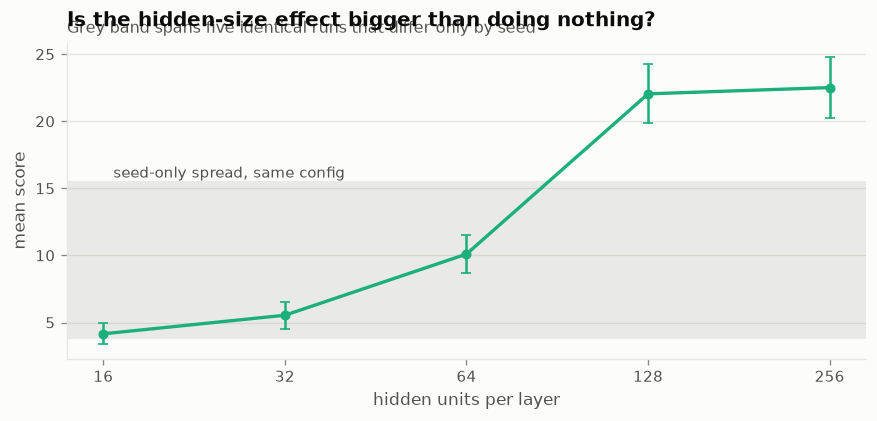

In [5]:
fig, ax = new_figure(height=3.4)

# Seed replicates as the reference band, drawn behind everything.
low, high = seeds["mean_score"].min(), seeds["mean_score"].max()
ax.axhspan(low, high, color=INK_FAINT, alpha=0.16, linewidth=0)
ax.text(hidden["hidden"].iloc[0], high, "  seed-only spread, same config",
        va="bottom", fontsize=9, color=INK_SOFT)

ax.plot(hidden["hidden"], hidden["mean_score"], color=colour_for("dqn"),
        marker="o", label="varying hidden size")
ax.errorbar(hidden["hidden"], hidden["mean_score"],
            yerr=1.96 * hidden["stderr"], fmt="none",
            ecolor=colour_for("dqn"), elinewidth=1.5, capsize=3)
ax.set_xscale("log", base=2)
ax.set_xticks(hidden["hidden"], [str(h) for h in hidden["hidden"]])
finish(ax, title="Is the hidden-size effect bigger than doing nothing?",
       subtitle="Grey band spans five identical runs that differ only by seed",
       xlabel="hidden units per layer", ylabel="mean score", legend=False)
plt.show()

## 3. Who the GA trains against

The multiplayer version of the same question. During training, the other seats are
filled by a fixed opponent — `random`, or a previously trained model. Does facing a
harder opponent produce a stronger agent?

Note this is training against a **fixed snapshot**, not self-play: the opponent does
not improve alongside the learner. True co-evolution is a different (and harder) thing.

All three variants are then scored against the *same* `random` opponent, because a
score against your own training opponent is not comparable to anyone else's.

In [6]:
opponent_rows = sweep(
    "ga", "snake", "opponent", ["random", "ga", "dqn"],
    players=2, generations=GA_GENERATIONS, population=GA_POPULATION,
    arena_games=ARENA_GAMES, arena_opponent="random",
)
opponents = pd.DataFrame(opponent_rows)
opponents[["opponent", "model", "train_seconds", "holdout_score",
           "mean_score", "stderr", "win_rate"]].round(3)

training ga-opponent-random … 

  2.9s train · score    23.66 ± 2.38 · win 98.3%
training ga-opponent-ga … 

 17.7s train · score    23.90 ± 2.39 · win 98.5%
training ga-opponent-dqn … 

 32.0s train · score    23.22 ± 2.36 · win 98.2%


,opponent,model,train_seconds,holdout_score,mean_score,stderr,win_rate
0,random,ga-opponent-random,2.9,24.651,23.657,1.215,0.983
1,ga,ga-opponent-ga,17.7,84.012,23.895,1.220,0.985
2,dqn,ga-opponent-dqn,32.0,48.873,23.224,1.205,0.982


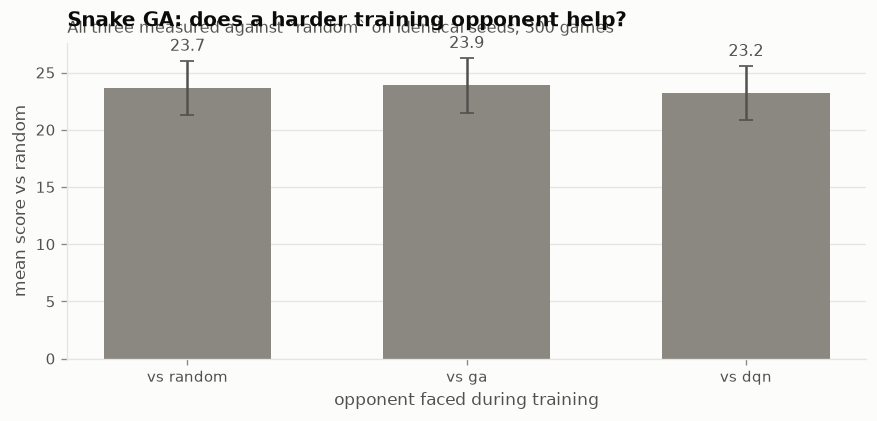

best  : trained vs ga      score 23.90 [21.50, 26.29]
worst : trained vs dqn     score 23.22 [20.86, 25.58]
separable: False


In [7]:
fig, ax = new_figure(height=3.4)
positions = range(len(opponents))
ax.bar(positions, opponents["mean_score"], width=0.6,
       color=[colour_for(f"trained-vs-{o}") for o in opponents["opponent"]])
ax.errorbar(positions, opponents["mean_score"], yerr=1.96 * opponents["stderr"],
            fmt="none", ecolor=INK_SOFT, elinewidth=1.5, capsize=4)
for i, row in opponents.iterrows():
    ax.annotate(f"{row['mean_score']:.1f}",
                (i, row["mean_score"] + 1.96 * row["stderr"]),
                textcoords="offset points", xytext=(0, 6), ha="center",
                fontsize=9.5, color=INK_SOFT)
ax.set_xticks(list(positions), [f"vs {o}" for o in opponents["opponent"]])
finish(ax, title="Snake GA: does a harder training opponent help?",
       subtitle=f"All three measured against `random` on identical seeds, {ARENA_GAMES} games",
       xlabel="opponent faced during training", ylabel="mean score vs random",
       legend=False)
plt.show()

best, worst = opponents.iloc[opponents["mean_score"].idxmax()], opponents.iloc[opponents["mean_score"].idxmin()]
print(f"best  : trained vs {best['opponent']:<7} score {best['mean_score']:.2f} "
      f"[{best['score_low']:.2f}, {best['score_high']:.2f}]")
print(f"worst : trained vs {worst['opponent']:<7} score {worst['mean_score']:.2f} "
      f"[{worst['score_low']:.2f}, {worst['score_high']:.2f}]")
print("separable:", separable(best["score_low"], best["score_high"],
                              worst["score_low"], worst["score_high"]))

## 4. Round robin

Scoring against `random` only tells you who beats `random`. This plays the variants
against **each other**, which is the question you actually care about.

Read the diagonal as undefined and the colour as distance from an even match: blue
means the row model beats the column model, red means it loses.

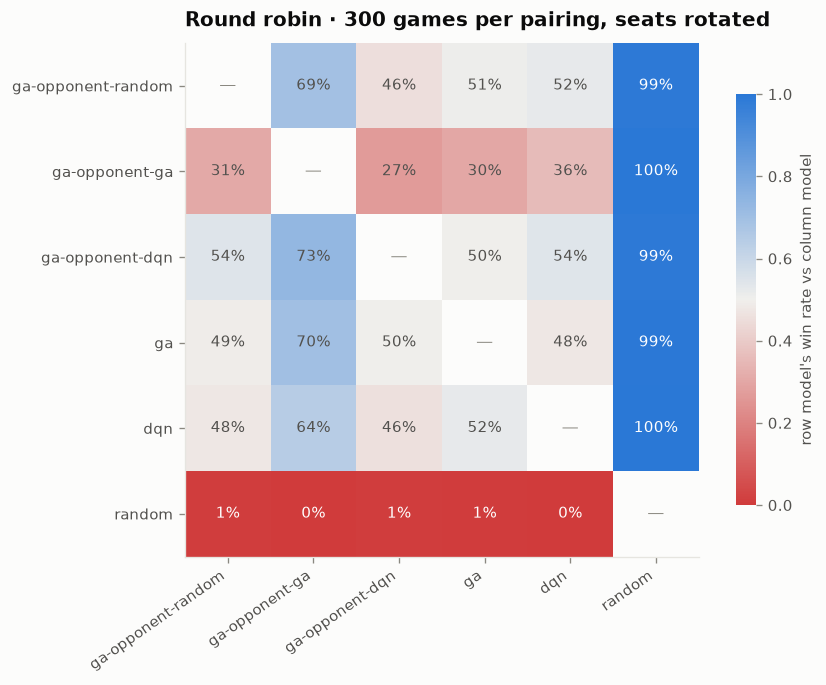

,ga-opponent-random,ga-opponent-ga,ga-opponent-dqn,ga,dqn,random
ga-opponent-random,NaN,0.692,0.457,0.507,0.522,0.990
ga-opponent-ga,0.308,NaN,0.267,0.302,0.357,0.997
ga-opponent-dqn,0.543,0.733,NaN,0.497,0.540,0.988
ga,0.493,0.698,0.503,NaN,0.480,0.993
dqn,0.478,0.643,0.460,0.520,NaN,0.997
random,0.010,0.003,0.012,0.007,0.003,NaN


In [8]:
contenders = list(opponents["model"]) + ["ga", "dqn", "random"]
rr = round_robin("snake", contenders, games=ARENA_GAMES, players=2)

matrix = np.array([[rr["win_rate"][a][b] for b in contenders] for a in contenders])

fig, ax = plt.subplots(figsize=(7.4, 5.6))
img = ax.imshow(matrix, cmap=diverging_cmap(), vmin=0.0, vmax=1.0)
ax.set_xticks(range(len(contenders)), contenders, rotation=35, ha="right")
ax.set_yticks(range(len(contenders)), contenders)
ax.grid(False)

for i in range(len(contenders)):
    for j in range(len(contenders)):
        value = matrix[i, j]
        if np.isnan(value):
            ax.text(j, i, "—", ha="center", va="center", color=INK_FAINT)
            continue
        # Ink, not the cell colour: text must stay readable on every step.
        shade = "#ffffff" if abs(value - 0.5) > 0.32 else INK_SOFT
        ax.text(j, i, f"{value:.0%}", ha="center", va="center",
                fontsize=9, color=shade)

bar = fig.colorbar(img, ax=ax, shrink=0.8)
bar.set_label("row model's win rate vs column model", color=INK_SOFT, fontsize=9)
bar.outline.set_visible(False)
ax.set_title(f"Round robin · {ARENA_GAMES} games per pairing, seats rotated")
plt.show()

pd.DataFrame(matrix, index=contenders, columns=contenders).round(3)

In [9]:
# Overall standing, and whether the top two are actually separable.
standing = (pd.DataFrame(matrix, index=contenders, columns=contenders)
            .mean(axis=1, skipna=True)
            .sort_values(ascending=False)
            .rename("mean win rate"))
print(standing.round(3).to_string(), "\n")

top, second = standing.index[0], standing.index[1]
low, high = rr["interval"][top][second]
print(f"{top} vs {second}: {rr['win_rate'][top][second]:.1%} "
      f"[{low:.1%}, {high:.1%}]")
print("a real ranking" if low > 0.5 else
      "NOT separable at this sample size — raise ARENA_GAMES or accept the tie")

ga-opponent-dqn       0.660
ga                    0.634
ga-opponent-random    0.633
dqn                   0.620
ga-opponent-ga        0.446
random                0.007 

ga-opponent-dqn vs ga: 49.7% [44.0%, 55.3%]
NOT separable at this sample size — raise ARENA_GAMES or accept the tie


## Running your own sweep

Any parameter either trainer accepts can be swept. A typo raises rather than being
silently ignored:

```python
sweep("dqn", "snake", "lr", [1e-4, 3e-4, 1e-3, 3e-3], players=2)
sweep("dqn", "snake", "gamma", [0.9, 0.95, 0.99], players=2, hidden=64)
sweep("ga",  "2048",  "population", [10, 20, 40, 80])
sweep("ga",  "snake", "mutation_rate", [0.1, 0.3, 0.5], players=2)
```

`arena_games` and `arena_opponent` control the measurement afterwards, not the
training — named distinctly because the DQN trainer has its own `eval_games`.

**Three habits worth keeping:**

1. **Always run the seed sweep too.** A parameter sweep without a noise floor is
   unreadable — you cannot tell an effect from the variance you would have got anyway.
2. **Score every variant against a common opponent.** A model measured against its own
   training opponent is not comparable to one measured against something else.
3. **Check whether intervals overlap before ranking.** `separable()` does it for you.
   Most sweeps at `FAST=True` settings will not separate, and that is the honest answer
   rather than a failure.